# Notebook 08— Manual m-Order Inspection

Interactive neuron-by-neuron visual verification of the derivative-order
assignment (m=1 vs m=2) for the m≥1 subset from nb05d.

**Purpose:**
Automated order selection (even with the ΔR² > 0.05 parsimonious threshold)
can still mis-classify low-SNR neurons whose signed RF maps are too noisy
for reliable lobe counting.  This notebook lets you inspect each candidate
neuron visually — raw RF map alongside re-fitted m=0, m=1, m=2 models
(using multi-start LM) — and record your manual judgement to a crash-safe CSV.

**Workflow:**
1. Load nb05d m≥1 population
2. Pre-load all RF maps by container (one ridge solve per container)
3. Step through neurons with the widget, recording Accept m=0/1/2 or Skip
4. Merge manual judgements → `m_final` column for downstream analyses

**Output:**
- `outputs/rf_params/order_full/manual_m_judgements.csv` — raw judgements
- `outputs/rf_params/order_full/rf_params_order_manual_corrected.csv` — merged final df

**References:**
- Lindeberg (2021) Heliyon Figs 12-13 (m=1 examples) and 16-18 (m=2 examples)
  for visual calibration of acceptable fits.
- Tony email (24 Mar 2026): suggested multiple random initialisations.
- Daria email (28 Mar 2026): planned manual inspection + multi-start as next steps.

In [1]:
import sys, warnings, os, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from IPython.display import display, clear_output
from pathlib import Path
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import RidgeCV, Ridge
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

sys.path.insert(0, os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study/src'))
from rf_analysis.sparse_noise import (
    fit_rf_by_order,
    classify_rf_order,
    _build_design_matrix,
    _pixel_size,
    _LAMBDA_GRID,
    gaussian_deriv_m0,
    gaussian_deriv_m1,
    gaussian_deriv_m2,
)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [2]:
# ---------------------------------------------------------------------------
# Paths — mirror nb05d exactly
# ---------------------------------------------------------------------------
base_dir    = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
cache_dir   = base_dir / 'data' / 'cache'
lists_dir   = base_dir / 'data' / 'experiment_lists'
outputs_dir = base_dir / 'outputs' / 'rf_params'
nb05d_dir   = outputs_dir / 'order_full'         # nb05d CSVs (read)
nb07_dir    = nb05d_dir                           # write judgements alongside nb05d CSVs

COMBINED_CSV    = nb05d_dir / 'rf_params_order_all_containers.csv'
JUDGEMENT_CSV   = nb07_dir  / 'manual_m_judgements.csv'
CORRECTED_CSV   = nb07_dir  / 'rf_params_order_manual_corrected.csv'

manifest_path = str(cache_dir / 'manifest.json')
boc = BrainObservatoryCache(manifest_file=manifest_path)

# Session-C experiment lookup (same filter as nb05d)
batch_df  = pd.read_csv(lists_dir / 'all_l23_excitatory_experiments.csv')
verify_df = pd.read_csv(lists_dir / 'downloaded_all_l23_excitatory_experiments.csv')
downloaded = set(verify_df[verify_df['exists']]['experiment_id'].tolist())
container_meta = pd.read_csv(lists_dir / 'container_neuron_counts.csv')
complete_ids   = set(container_meta['container_id'].tolist())

session_c = batch_df[
    batch_df['session_type'].str.contains('C') &
    batch_df['id'].isin(downloaded) &
    batch_df['experiment_container_id'].isin(complete_ids)
].copy()
container_to_exp = dict(zip(session_c['experiment_container_id'], session_c['id']))

print(f'Session C containers: {len(container_to_exp)}')
print(f'Combined CSV: {COMBINED_CSV}')
assert COMBINED_CSV.exists(), 'Run nb05d first to generate the combined CSV.'

Session C containers: 17
Combined CSV: /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/order_full/rf_params_order_all_containers.csv


In [3]:
# ---------------------------------------------------------------------------
# batch_get_rf_maps_safe — identical to nb05d Cell 3
# Returns {cell_id: (rf_map_2d, pix_size_deg)}
# ---------------------------------------------------------------------------
def batch_get_rf_maps_safe(dataset, requested_ids,
                            n_lags=8, response_delay=4, response_window=5):
    exp_cells = list(dataset.get_cell_specimen_ids())
    req_set   = set(int(c) for c in requested_ids)
    valid_ids = [c for c in exp_cells if c in req_set]
    if not valid_ids:
        raise ValueError('No requested cell_ids found in experiment.')

    stim_name = next((s for s in dataset.list_stimuli() if 'sparse_noise' in s), None)
    if stim_name is None:
        raise ValueError('No sparse noise stimulus.')

    stim_table = dataset.get_stimulus_table(stim_name)
    tr         = dataset.get_locally_sparse_noise_stimulus_template(stimulus=stim_name)
    template   = tr[0] if isinstance(tr, tuple) else tr
    n_tf, grid_h, grid_w = template.shape
    on_val, off_val = int(template.max()), int(template.min())
    pix_size        = _pixel_size(stim_name)

    starts        = stim_table['start'].values.astype(int)
    frame_indices = stim_table['frame'].values.astype(int)

    _, all_dff    = dataset.get_dff_traces(cell_specimen_ids=valid_ids)
    n_cells, n_tp = all_dff.shape

    X = _build_design_matrix(template, frame_indices, on_val, off_val,
                              grid_h, grid_w, n_lags)

    win_idx  = (starts + response_delay)[:, None] + np.arange(response_window)
    in_bnds  = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)
    dff_wins = all_dff[:, win_safe]
    dff_wins[:, ~in_bnds] = np.nan
    Y = np.nanmean(dff_wins, axis=2).T
    Y = np.where(np.isnan(Y), 0.0, Y).astype(np.float64)

    frame_valid  = (frame_indices >= 0) & (frame_indices < n_tf)
    X_fit, Y_fit = X[frame_valid].astype(np.float64), Y[frame_valid]
    if X_fit.shape[0] < 20:
        raise ValueError('Too few valid presentations.')

    try:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None,
                      fit_intercept=True, alpha_per_target=True)
        rcv.fit(X_fit, Y_fit)
        W = np.atleast_2d(rcv.coef_)
    except TypeError:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True)
        rcv.fit(X_fit, Y_fit.mean(axis=1, keepdims=True))
        r = Ridge(alpha=float(rcv.alpha_), fit_intercept=True)
        r.fit(X_fit, Y_fit)
        W = np.atleast_2d(r.coef_)

    rf_out = {}
    for i, cid in enumerate(valid_ids):
        strf     = W[i].reshape(n_lags, grid_h, grid_w)
        best_lag = int(np.argmax([np.abs(strf[l]).max() for l in range(n_lags)]))
        rf_out[cid] = (strf[best_lag], pix_size)
    return rf_out

print('batch_get_rf_maps_safe defined')

batch_get_rf_maps_safe defined


In [4]:
# ---------------------------------------------------------------------------
# Load nb05d combined CSV, filter to m>=1 candidates
# Sort: r_squared descending so best-quality RFs come first
# ---------------------------------------------------------------------------
all_df = pd.read_csv(COMBINED_CSV)
for col in ['sigma','theta','kappa','r_squared','r2_m0','r2_m1','r2_m2',
            'phi','phi_confidence','theta_hybrid','sigma_x','sigma_y']:
    if col in all_df.columns:
        all_df[col] = pd.to_numeric(all_df[col], errors='coerce')

candidates = (
    all_df[all_df['derivative_order'].isin([1, 2])]
    .sort_values('r_squared', ascending=False)
    .reset_index(drop=True)
    .copy()
)

print(f'Total nb05d neurons:  {len(all_df):,}')
print(f'm>=1 candidates:      {len(candidates):,}')
print(f'  m=1: {(candidates["derivative_order"]==1).sum()}')
print(f'  m=2: {(candidates["derivative_order"]==2).sum()}')
print(f'Containers represented: {candidates["container_id"].nunique()}')
print(f'R² range: {candidates["r_squared"].min():.3f} – {candidates["r_squared"].max():.3f}')

Total nb05d neurons:  885
m>=1 candidates:      408
  m=1: 99
  m=2: 309
Containers represented: 17
R² range: 0.301 – 0.773


In [5]:
# ---------------------------------------------------------------------------
# Pre-load all RF maps for m>=1 neurons (one ridge solve per container).
# Cached in rf_map_cache: {cell_id: (rf_map_2d, pix_size_deg)}
# This takes ~3-5 min per container — run once, then inspection is instant.
# ---------------------------------------------------------------------------
rf_map_cache   = {}   # {cell_id: (rf_map, pix_size)}
dataset_cache  = {}   # {container_id: dataset}  — kept open to avoid re-reads
failed_containers = []

by_container = candidates.groupby('container_id')['cell_id'].apply(list)
t0 = time.time()

for container_id, cids in by_container.items():
    if container_id not in container_to_exp:
        print(f'  [SKIP] {container_id}: not in session_c')
        continue
    exp_id = container_to_exp[container_id]
    try:
        if container_id not in dataset_cache:
            dataset_cache[container_id] = boc.get_ophys_experiment_data(exp_id)
        dataset = dataset_cache[container_id]
        maps    = batch_get_rf_maps_safe(dataset, cids)
        rf_map_cache.update(maps)
        print(f'  Container {container_id}: {len(maps)}/{len(cids)} maps loaded')
    except Exception as e:
        failed_containers.append(container_id)
        print(f'  [FAIL] Container {container_id}: {e}')

print(f'\nTotal RF maps cached: {len(rf_map_cache)}')
print(f'Failed containers:    {failed_containers}')
print(f'Elapsed: {(time.time()-t0)/60:.1f} min')

  Container 511507650: 26/26 maps loaded
  Container 511509529: 16/16 maps loaded
  Container 511510650: 7/7 maps loaded
  Container 511510670: 20/20 maps loaded
  Container 511510718: 21/21 maps loaded
  Container 511510736: 10/10 maps loaded
  Container 511510855: 32/32 maps loaded
  Container 650389885: 16/16 maps loaded
  Container 652842570: 29/29 maps loaded
  Container 653125128: 44/44 maps loaded
  Container 661437138: 14/14 maps loaded
  Container 661732156: 25/25 maps loaded
  Container 666589599: 11/11 maps loaded
  Container 680156909: 31/31 maps loaded
  Container 682734790: 25/25 maps loaded
  Container 688678764: 71/71 maps loaded
  Container 701412138: 10/10 maps loaded

Total RF maps cached: 408
Failed containers:    []
Elapsed: 16.0 min


In [6]:
# ---------------------------------------------------------------------------
# Fitting helpers
# ---------------------------------------------------------------------------
N_RANDOM_STARTS = 15   # per order; same as the updated sparse_noise.py default
SMOOTH_SIGMA    = 0.75

_MODEL_FNS = {0: gaussian_deriv_m0, 1: gaussian_deriv_m1, 2: gaussian_deriv_m2}

def refit_all_orders(rf_map, pix_size, seed=None):
    """Re-fit m=0,1,2 with multi-start. Returns {m: (params, quality, fitted_map)}."""
    rf_on  = np.maximum(rf_map,  0.0)
    rf_off = np.maximum(-rf_map, 0.0)
    grid_h, grid_w = rf_map.shape
    Y, X = np.mgrid[0:grid_h, 0:grid_w].astype(float)
    xy   = (X, Y)

    results = {}
    rng = np.random.default_rng(seed)
    for m in [0, 1, 2]:
        child_seed = int(rng.integers(0, 2**31))
        try:
            p, q = fit_rf_by_order(
                rf_on, rf_off, m=m,
                pixel_size_deg=pix_size,
                smooth_sigma=SMOOTH_SIGMA,
                n_random_starts=N_RANDOM_STARTS,
                seed=child_seed,
            )
            # Reconstruct 2D fitted map in *pixel* space
            # sigma_x/y in all_df are in degrees; fit_rf_by_order popt is in pixels
            # We re-derive popt from params dict to reconstruct
            # (fit_rf_by_order applies gaussian_filter internally; reproduce that)
            if SMOOTH_SIGMA > 0:
                rf_work = gaussian_filter(rf_map, sigma=SMOOTH_SIGMA)
            else:
                rf_work = rf_map.copy()
            # fitted map: use the best-popt stored via the quality 'r_squared'
            # We don't have popt directly, so we call fit_rf_by_order a second time
            # --- BUT that's expensive. Instead reconstruct from params dict:
            su_px  = p['sigma_x'] / pix_size   # back to pixels
            sv_px  = p['sigma_y'] / pix_size
            x0_px  = p['x0']     / pix_size
            y0_px  = p['y0']     / pix_size
            theta_r = np.deg2rad(p['theta'])
            A, b    = p['amplitude'], 0.0
            popt_approx = [A, x0_px, y0_px, su_px, sv_px, theta_r, b]
            fitted = _MODEL_FNS[m](xy, *popt_approx).reshape(grid_h, grid_w)
            results[m] = (p, q, fitted)
        except Exception as e:
            results[m] = (None, {'r_squared': np.nan, 'message': str(e)}, None)
    return results


def plot_neuron(cell_id, rf_map, fit_results, auto_m, pix_size, row_info):
    """
    4-panel figure: raw signed RF | m=0 fit | m=1 fit | m=2 fit.
    Returns fig.
    """
    r2s = {m: fit_results[m][1]['r_squared'] for m in [0,1,2]}

    # Parsimonious selection (ΔR² > 0.05 over m=0)
    r2_m0 = r2s[0] if not np.isnan(r2s[0]) else 0.0
    best_auto = auto_m
    best_refit = max([0,1,2], key=lambda m: r2s[m] if not np.isnan(r2s[m]) else -np.inf)
    if best_refit != 0 and (r2s[best_refit] - r2_m0 < 0.05):
        best_refit = 0

    delta_01 = r2s[1] - r2s[0]
    delta_02 = r2s[2] - r2s[0]

    fig = plt.figure(figsize=(18, 4.2))
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.04)

    cre   = row_info.get('cre_line', '')[:20]
    depth = row_info.get('depth_um', '')
    r2_nb = row_info.get('r_squared', np.nan)
    fig.suptitle(
        f'Cell {cell_id}   |   container {row_info.get("container_id","")}   '
        f'|   {cre}  {depth}μm   |   '
        f'nb05d auto m*={auto_m}  R²={r2_nb:.3f}   |   '
        f'refit m*={best_refit}   '
        f'ΔR²(m1-m0)={delta_01:+.3f}   ΔR²(m2-m0)={delta_02:+.3f}',
        fontsize=9, fontweight='bold'
    )

    vmax = np.nanpercentile(np.abs(rf_map), 98)
    imkw = dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                aspect='auto', origin='lower', interpolation='nearest')

    titles = ['Raw RF (signed)', 'm=0  (blob)', 'm=1  (edge)', 'm=2  (bar)']
    maps   = [rf_map] + [fit_results[m][2] for m in [0,1,2]]

    for col, (title, img) in enumerate(zip(titles, maps)):
        ax = fig.add_subplot(gs[0, col])
        if img is not None:
            ax.imshow(img, **imkw)
        else:
            ax.set_facecolor('#222')
            ax.text(0.5, 0.5, 'fit failed', color='white',
                    ha='center', va='center', transform=ax.transAxes)

        if col == 0:
            subtitle = ''
        else:
            m   = col - 1
            r2  = r2s[m]
            rmi = fit_results[m][0].get('r2_improvement', 0.0) if fit_results[m][0] else 0.0
            flags = []
            if m == best_refit:
                flags.append('★ refit best')
            if m == auto_m:
                flags.append('▲ nb05d')
            if rmi > 0.05:
                flags.append(f'⚠ multistart +{rmi:.2f}')
            subtitle = f'R²={r2:.3f}' + (f'  {" ".join(flags)}' if flags else '')

        bold = (col > 0 and col - 1 == best_refit)
        ax.set_title(f'{title}\n{subtitle}',
                     fontsize=8.5,
                     fontweight='bold' if bold else 'normal',
                     color='#e67e22' if bold else 'black')
        ax.axis('off')

    return fig

print('Helpers defined')

Helpers defined


In [7]:
# ---------------------------------------------------------------------------
# Load or initialise judgement store
# m_manual: -1=Skip, 0, 1, 2
# ---------------------------------------------------------------------------
if JUDGEMENT_CSV.exists():
    judged_df  = pd.read_csv(JUDGEMENT_CSV)
    judged_ids = set(judged_df['cell_id'].tolist())
    print(f'Loaded {len(judged_df)} existing judgements from {JUDGEMENT_CSV}')
else:
    judged_df  = pd.DataFrame(columns=['cell_id', 'm_manual', 'note', 'flagged'])
    judged_ids = set()
    print('Starting fresh judgement store.')

# Only inspect neurons whose RF maps loaded successfully
inspectable = candidates[candidates['cell_id'].isin(rf_map_cache)].reset_index(drop=True)
remaining   = inspectable[~inspectable['cell_id'].isin(judged_ids)]
print(f'Inspectable neurons: {len(inspectable)}')
print(f'Already judged:      {len(judged_ids)}')
print(f'Remaining:           {len(remaining)}')

Starting fresh judgement store.
Inspectable neurons: 408
Already judged:      0
Remaining:           408


Neuron 231/408  |  cell_id=701731817  |  container=688678764  |  Slc17a7-IRES2-Cre  205μm
nb05d auto m*=2  R²=0.415
  m=0  R²=0.427
  m=1  R²=0.322 ⚠ multistart local-min
  m=2  R²=0.417
Suggested: m=0  (ΔR²(m1-m0)=-0.105  ΔR²(m2-m0)=-0.009)


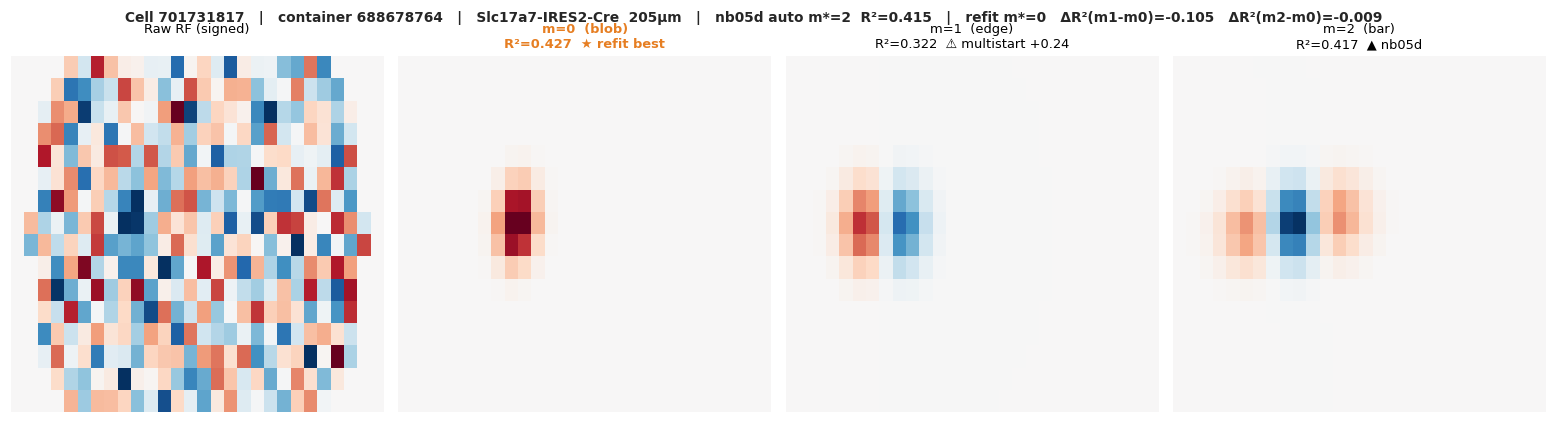

In [473]:
# ---------------------------------------------------------------------------
# Manual inspection — re-run this cell to see the current neuron
# Change CURRENT_IDX to jump, or just keep re-running to go forward
# ---------------------------------------------------------------------------
if 'CURRENT_IDX' not in dir():
    CURRENT_IDX = _first_unjudged()

row     = inspectable.iloc[CURRENT_IDX]
cid     = int(row['cell_id'])
rf_map, pix = rf_map_cache[cid]
auto_m  = int(row['derivative_order'])

print(f"Neuron {CURRENT_IDX+1}/{len(inspectable)}  |  cell_id={cid}  "
      f"|  container={row['container_id']}  |  {row['cre_line']}  {row['depth_um']}μm")
print(f"nb05d auto m*={auto_m}  R²={row['r_squared']:.3f}")
if cid in judged_ids:
    prev = judged_df[judged_df['cell_id']==cid].iloc[-1]
    print(f"↩  Already judged: m={prev['m_manual']}  note='{prev['note']}'  flag={prev['flagged']}")

_fit_cache = refit_all_orders(rf_map, pix, seed=cid)
r2s = {m: _fit_cache[m][1]['r_squared'] for m in [0,1,2]}
r2_m0 = r2s[0] if not np.isnan(r2s[0]) else 0.0
_refit_best = max([0,1,2], key=lambda m: r2s[m] if not np.isnan(r2s[m]) else -np.inf)
if _refit_best != 0 and (r2s[_refit_best] - r2_m0 < 0.05):
    _refit_best = 0

for m in [0,1,2]:
    p = _fit_cache[m][0]
    imp = p.get('r2_improvement', 0) if p else 0
    flag = ' ⚠ multistart local-min' if imp > 0.05 else ''
    print(f"  m={m}  R²={r2s[m]:.3f}{flag}")
print(f"Suggested: m={_refit_best}  (ΔR²(m1-m0)={r2s[1]-r2_m0:+.3f}  ΔR²(m2-m0)={r2s[2]-r2_m0:+.3f})")

fig = plot_neuron(cid, rf_map, _fit_cache, auto_m, pix, row.to_dict())
plt.tight_layout()
plt.show()

In [474]:
# ---------------------------------------------------------------------------
# Fill in your judgement, then run this cell, then re-run Cell 8A
# ---------------------------------------------------------------------------
M_ACCEPT = _refit_best   # ← change to 0, 1, or 2; or -1 to skip
NOTE     = ''            # ← optional free text
FLAG     = False         # ← True to mark for second-pass review

# --- save ---
row = inspectable.iloc[CURRENT_IDX]
cid = int(row['cell_id'])

new_row   = pd.DataFrame([{'cell_id': cid, 'm_manual': M_ACCEPT,
                            'note': NOTE, 'flagged': FLAG}])
judged_df  = pd.concat([judged_df[judged_df['cell_id'] != cid], new_row],
                        ignore_index=True)
judged_ids = set(judged_df['cell_id'].tolist())
judged_df.to_csv(JUDGEMENT_CSV, index=False)

done = len(judged_ids)
print(f"✓ Saved  cell {cid}  m={M_ACCEPT}  ({done}/{len(inspectable)} done)")

# advance to next un-judged
CURRENT_IDX = _first_unjudged(CURRENT_IDX + 1)
print(f"Next: index {CURRENT_IDX}  →  re-run Cell 8A")

✓ Saved  cell 701731817  m=0  (231/408 done)
Next: index 231  →  re-run Cell 8A


In [475]:
# ---------------------------------------------------------------------------
# Review summary — run after inspection session
# ---------------------------------------------------------------------------
if JUDGEMENT_CSV.exists():
    judged_df = pd.read_csv(JUDGEMENT_CSV)

print(f'Total judged:  {len(judged_df)}')
print(f'Still pending: {len(inspectable) - len(judged_ids)}')
print()
print('Manual m distribution:')
print(judged_df['m_manual'].value_counts().sort_index()
      .rename({-1:'Skip', 0:'m=0', 1:'m=1', 2:'m=2'}))
print()
print(f'Flagged for review: {judged_df["flagged"].sum()}')

# Compare auto vs manual
merged_check = candidates.merge(
    judged_df.rename(columns={'m_manual': 'm_manual'}),
    on='cell_id', how='inner'
)
merged_check = merged_check[merged_check['m_manual'] >= 0]   # exclude skips
agree        = (merged_check['derivative_order'] == merged_check['m_manual']).mean()
print(f'\nAuto / manual agreement (non-skipped): {agree:.1%}')

# Crosstab auto vs manual
print()
print('Crosstab (rows=auto, cols=manual):')
print(pd.crosstab(merged_check['derivative_order'],
                  merged_check['m_manual'],
                  rownames=['auto'], colnames=['manual']))

Total judged:  231
Still pending: 177

Manual m distribution:
Skip      6
m=0     210
m=1      13
m=2       2
Name: m_manual, dtype: int64

Flagged for review: 6

Auto / manual agreement (non-skipped): 6.2%

Crosstab (rows=auto, cols=manual):
manual    0   1  2
auto              
1        27  12  0
2       183   1  2


In [476]:
# ---------------------------------------------------------------------------
# Review flagged neurons
# ---------------------------------------------------------------------------
flagged = judged_df[judged_df['flagged'] == True]
print(f'{len(flagged)} neurons flagged for review:')
if len(flagged):
    display(flagged.merge(candidates[['cell_id','derivative_order','r_squared',
                                       'r2_m0','r2_m1','r2_m2',
                                       'container_id','cre_line','depth_um']],
                          on='cell_id', how='left'))

6 neurons flagged for review:


,cell_id,m_manual,note,flagged,derivative_order,r_squared,r2_m0,r2_m1,r2_m2,container_id,cre_line,depth_um
0,517420741,-1,looks like m=1,True,1,0.659777,0.104837,0.659777,0.642664,511510650,Cux2-CreERT2,175
1,517419591,0,low quality rf - looks most like large blob,True,2,0.629669,0.572047,0.540096,0.629669,511510650,Cux2-CreERT2,175
2,674569235,-1,looks like potential m=1,True,1,0.574755,0.177057,0.574755,0.324595,666589599,Slc17a7-IRES2-Cre,175
3,517513138,0,"diagonal structure, m=1 fit failed bad orienta...",True,2,0.440071,0.038199,0.353674,0.440071,511510855,Cux2-CreERT2,175
4,674570702,1,possibly noise,True,1,0.437783,0.357406,0.437783,0.416749,666589599,Slc17a7-IRES2-Cre,175
5,589170196,1,possibly noise,True,1,0.432550,0.324318,0.432550,0.287778,511510718,Cux2-CreERT2,175


In [477]:
# ---------------------------------------------------------------------------
# Merge manual judgements → m_final, save corrected population CSV
# m_final rules:
#   - Judged (m_manual >= 0): use m_manual
#   - Skipped (m_manual == -1): keep nb05d derivative_order
#   - Not judged at all: keep nb05d derivative_order
# ---------------------------------------------------------------------------
judged_df = pd.read_csv(JUDGEMENT_CSV)

corrected_df = all_df.merge(
    judged_df[['cell_id', 'm_manual', 'note', 'flagged']],
    on='cell_id', how='left'
)

# m_final: manual where judged and not skipped, else auto
corrected_df['m_final'] = np.where(
    corrected_df['m_manual'].notna() & (corrected_df['m_manual'] >= 0),
    corrected_df['m_manual'].astype('Int64'),
    corrected_df['derivative_order']
).astype(int)

corrected_df.to_csv(CORRECTED_CSV, index=False)

print(f'Saved {len(corrected_df):,} neurons → {CORRECTED_CSV}')
print()
print('m_final breakdown:')
print(corrected_df['m_final'].value_counts().sort_index()
      .rename({0:'m=0', 1:'m=1', 2:'m=2'}))
print()

# Convenience subsets for downstream notebooks
m1      = corrected_df[corrected_df['m_final'] == 1]
m2      = corrected_df[corrected_df['m_final'] == 2]
m1_m2   = corrected_df[corrected_df['m_final'].isin([1, 2])]

print(f'm=1 neurons:   {len(m1)}')
print(f'm=2 neurons:   {len(m2)}')
print(f'm>=1 neurons:  {len(m1_m2)}')
print(f'm=0 neurons:   {(corrected_df["m_final"]==0).sum()}')
print()
print('σ, κ for m>=1 (manual-corrected):')
print(m1_m2[['sigma','kappa','r_squared']].describe().round(3))

Saved 885 neurons → /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/order_full/rf_params_order_manual_corrected.csv

m_final breakdown:
m=0    687
m=1     73
m=2    125
Name: m_final, dtype: int64

m=1 neurons:   73
m=2 neurons:   125
m>=1 neurons:  198
m=0 neurons:   687

σ, κ for m>=1 (manual-corrected):
         sigma    kappa  r_squared
count  198.000  198.000    198.000
mean    10.896    3.434      0.374
std      3.981    2.393      0.066
min      4.638    1.004      0.301
25%      7.922    1.748      0.332
50%      9.801    2.705      0.364
75%     13.157    4.292      0.395
max     24.887   12.878      0.723


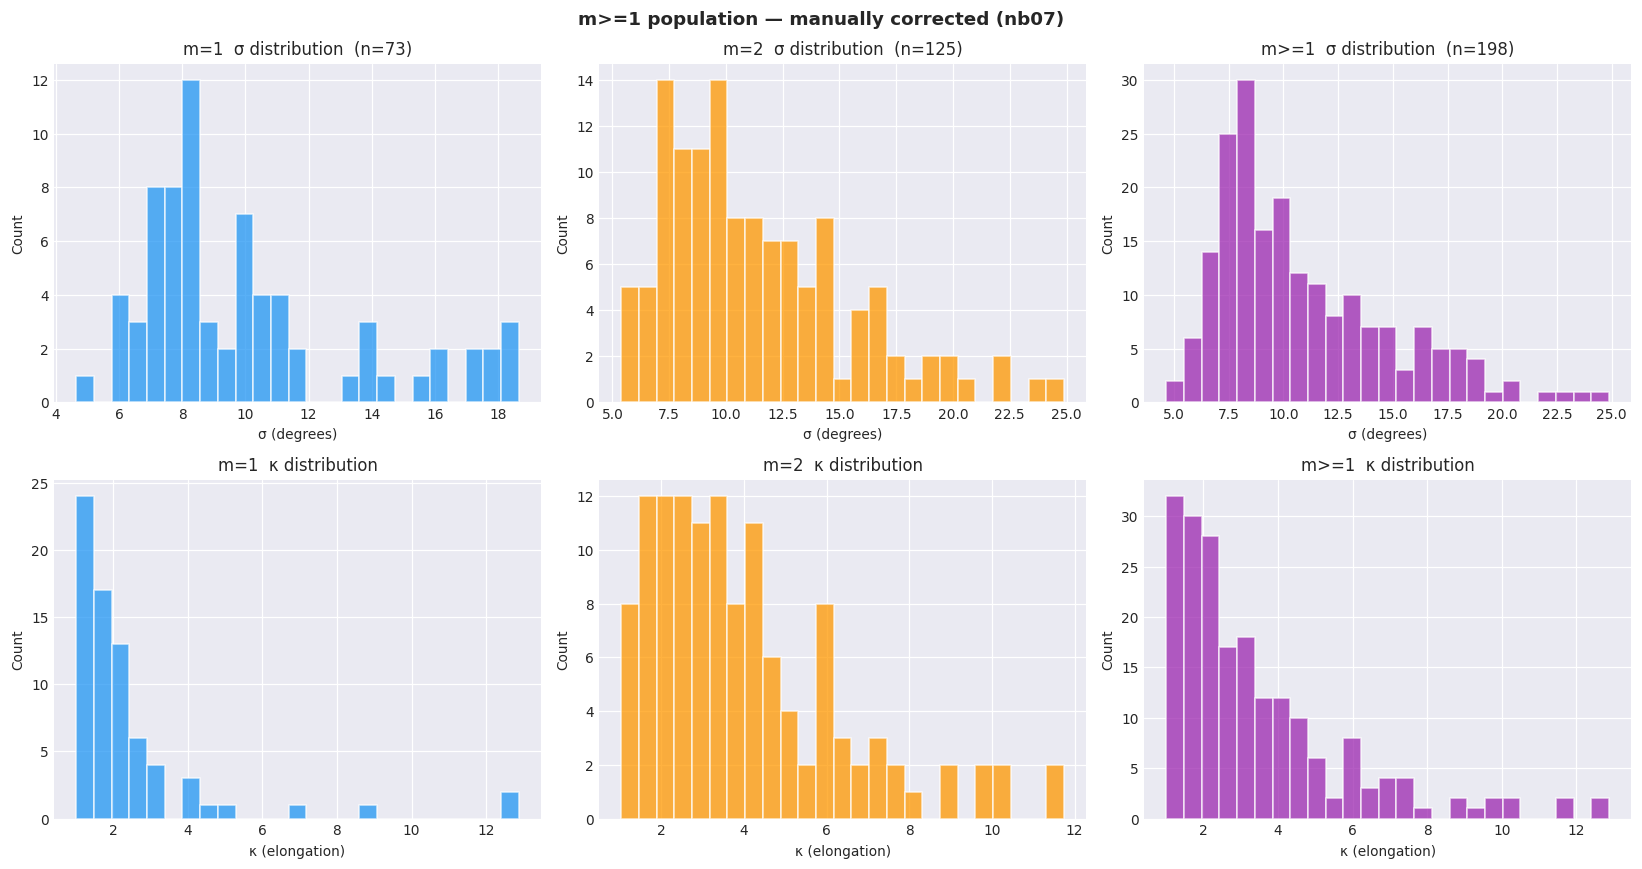

In [478]:
# ---------------------------------------------------------------------------
# Quick parameter overview plots (m=1 vs m=2 after manual correction)
# ---------------------------------------------------------------------------
ORDER_COLORS = {0: '#4CAF50', 1: '#2196F3', 2: '#FF9800'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('m>=1 population — manually corrected (nb07)',
             fontsize=12, fontweight='bold')

for ax, (m, label) in zip(axes[0], [(1,'m=1'), (2,'m=2'), (None,'m>=1')]):
    sub = m1_m2 if m is None else corrected_df[corrected_df['m_final']==m]
    col = '#9C27B0' if m is None else ORDER_COLORS[m]
    ax.hist(sub['sigma'].dropna(), bins=25, color=col, alpha=0.75, edgecolor='white')
    ax.set_xlabel('σ (degrees)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}  σ distribution  (n={len(sub)})')

for ax, (m, label) in zip(axes[1], [(1,'m=1'), (2,'m=2'), (None,'m>=1')]):
    sub = m1_m2 if m is None else corrected_df[corrected_df['m_final']==m]
    col = '#9C27B0' if m is None else ORDER_COLORS[m]
    ax.hist(sub['kappa'].dropna(), bins=25, color=col, alpha=0.75, edgecolor='white')
    ax.set_xlabel('κ (elongation)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}  κ distribution')

plt.tight_layout()
plt.savefig(nb07_dir / 'fig_07_manual_corrected_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()